# 05 — Inference, Debugging, and Business Decisions (Manual NumPy)

A useful model must be evaluated on unseen data, inspected for systematic errors, and embedded in a decision policy.


train (5000, 784) test (1000, 784)


              precision    recall  f1-score   support

           0      0.887     0.860     0.873       100
           1      0.823     0.930     0.873       100
           2      0.812     0.780     0.796       100
           3      0.851     0.740     0.791       100
           4      0.705     0.790     0.745       100
           5      0.708     0.680     0.694       100
           6      0.897     0.780     0.834       100
           7      0.785     0.730     0.756       100
           8      0.628     0.760     0.688       100
           9      0.694     0.680     0.687       100

    accuracy                          0.773      1000
   macro avg      0.779     0.773     0.774      1000
weighted avg      0.779     0.773     0.774      1000



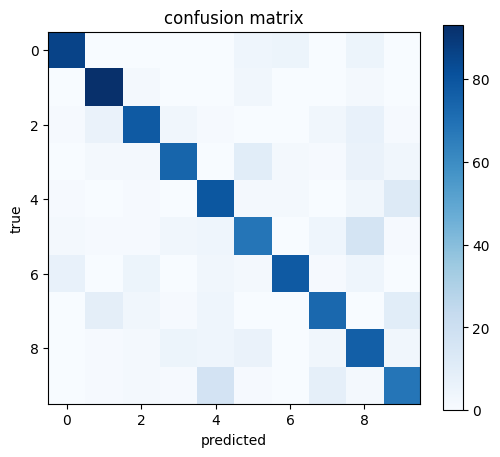

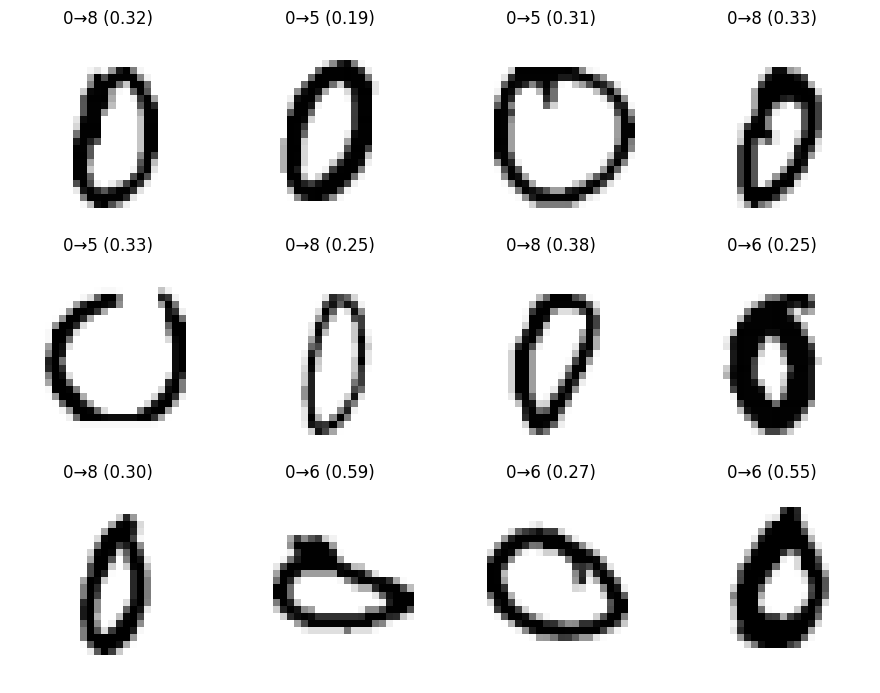

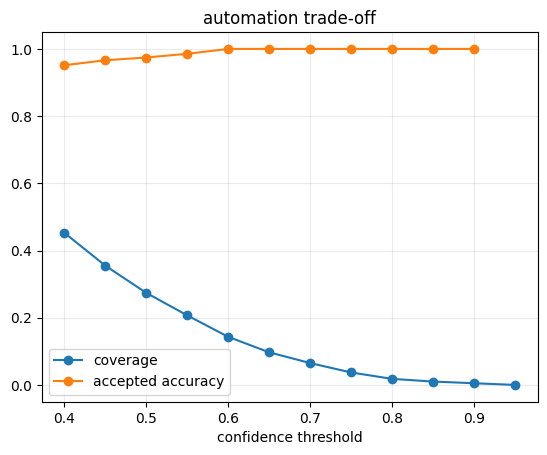

In [1]:
from pathlib import Path
import urllib.request, numpy as np
MNIST_URL='https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz'
CACHE=Path('data/cache/mnist.npz'); CACHE.parent.mkdir(parents=True,exist_ok=True)
if not CACHE.exists():
    print('Downloading official MNIST archive...')
    urllib.request.urlretrieve(MNIST_URL,CACHE)
with np.load(CACHE) as d:
    x_train_full,y_train_full=d['x_train'],d['y_train']
    x_test_full,y_test_full=d['x_test'],d['y_test']
def balanced(x,y,n):
    ids=np.concatenate([np.flatnonzero(y==c)[:n] for c in range(10)])
    return x[ids],y[ids]
x_train_img,y_train=balanced(x_train_full,y_train_full,500)
x_test_img,y_test=balanced(x_test_full,y_test_full,100)
x_train=x_train_img.reshape(len(x_train_img),-1).astype('float32')/255.0
x_test=x_test_img.reshape(len(x_test_img),-1).astype('float32')/255.0
print('train',x_train.shape,'test',x_test.shape)

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,classification_report
rng=np.random.default_rng(42);W1=rng.normal(0,np.sqrt(2/784),(784,64));b1=np.zeros((1,64));W2=rng.normal(0,np.sqrt(2/64),(64,10));b2=np.zeros((1,10));Y=np.eye(10)[y_train]
for _ in range(10):
 z=x_train@W1+b1;h=np.maximum(z,0);q=h@W2+b2;e=np.exp(q-q.max(1,keepdims=True));p=e/e.sum(1,keepdims=True);dz=(p-Y)/len(y_train);dW2=h.T@dz;db2=dz.sum(0,keepdims=True);dz1=(dz@W2.T)*(z>0);dW1=x_train.T@dz1;db1=dz1.sum(0,keepdims=True);W2-=.25*dW2;b2-=.25*db2;W1-=.25*dW1;b1-=.25*db1
z=x_test@W1+b1;h=np.maximum(z,0);q=h@W2+b2;e=np.exp(q-q.max(1,keepdims=True));p=e/e.sum(1,keepdims=True);pred=p.argmax(1);conf=p.max(1);print(classification_report(y_test,pred,digits=3))
cm=confusion_matrix(y_test,pred);plt.figure(figsize=(6,5));plt.imshow(cm,cmap='Blues');plt.colorbar();plt.title('confusion matrix');plt.xlabel('predicted');plt.ylabel('true');plt.show();wrong=np.flatnonzero(pred!=y_test)[:12];fig,axes=plt.subplots(3,4,figsize=(9,7))
for ax,i in zip(axes.ravel(),wrong):ax.imshow(x_test_img[i],cmap='gray_r');ax.set_title(f'{y_test[i]}→{pred[i]} ({conf[i]:.2f})');ax.axis('off')
plt.tight_layout();plt.show();ths=np.linspace(.4,.95,12);cov=[];acc=[]
for t in ths:
 m=conf>=t;cov.append(m.mean());acc.append((pred[m]==y_test[m]).mean() if m.any() else np.nan)
plt.plot(ths,cov,marker='o',label='coverage');plt.plot(ths,acc,marker='o',label='accepted accuracy');plt.legend();plt.grid(alpha=.25);plt.xlabel('confidence threshold');plt.title('automation trade-off');plt.show()


## Confidence is not correctness
A normalized softmax score is not a guarantee. Wrong predictions can still be confident. In production, low-confidence cases may be routed to review, while high-risk systems may require calibration and explicit abstention.


## Business interpretation
Imagine MNIST-like digit recognition inside document ingestion. Raising the confidence threshold can improve automated-decision accuracy while reducing automation coverage and increasing manual-review volume.

The operational optimum depends on **error cost + review capacity + latency + risk tolerance**, not accuracy alone.

### Final mental model
- forward pass = current belief
- loss = quantified error
- backprop = responsibility assignment
- update = parameter correction
- representation learning = changing hidden geometry
- inference = applying the learned function to unseen data
- business policy = turning model scores into actions
